<a href="https://colab.research.google.com/github/Monika-magic/ecommerce-sales-prediction-regression/blob/main/supermarket_sales_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Niiimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving supermarket_sales_50000.csv to supermarket_sales_50000.csv


In [ ]:
df = pd.read_csv("supermarket_sales_50000.csv")

In [ ]:
df.head()

,Date,Store_ID,Product_Category,Product,Quantity,Unit_Price,Discount,Customer_Count,Day,Sales
0,2024-01-01,S04,Dairy,Butter,17,123.10,10,15,Monday,1883.43
1,2024-01-01,S05,Dairy,Milk,29,482.61,10,16,Monday,12596.12
2,2024-01-01,S03,Dairy,Butter,38,370.05,10,21,Monday,12655.71
3,2024-01-01,S05,Snacks,Noodles,15,295.00,10,12,Monday,3982.50
4,2024-01-01,S05,Personal Care,Shampoo,28,228.66,15,23,Monday,5442.11


In [ ]:
df.shape

(50000, 10)

In [ ]:
df.columns

Index(['Date', 'Store_ID', 'Product_Category', 'Product', 'Quantity',
       'Unit_Price', 'Discount', 'Customer_Count', 'Day', 'Sales'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Date,0
Store_ID,0
Product_Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,0
Customer_Count,0
Day,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              50000 non-null  object 
 1   Store_ID          50000 non-null  object 
 2   Product_Category  50000 non-null  object 
 3   Product           50000 non-null  object 
 4   Quantity          50000 non-null  int64  
 5   Unit_Price        50000 non-null  float64
 6   Discount          50000 non-null  int64  
 7   Customer_Count    50000 non-null  int64  
 8   Day               50000 non-null  object 
 9   Sales             50000 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 3.8+ MB


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              50000 non-null  datetime64[ns]
 1   Store_ID          50000 non-null  object        
 2   Product_Category  50000 non-null  object        
 3   Product           50000 non-null  object        
 4   Quantity          50000 non-null  int64         
 5   Unit_Price        50000 non-null  float64       
 6   Discount          50000 non-null  int64         
 7   Customer_Count    50000 non-null  int64         
 8   Day               50000 non-null  object        
 9   Sales             50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 3.8+ MB


In [ ]:
df.describe()

,Date,Quantity,Unit_Price,Discount,Customer_Count,Sales
count,50000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,2024-12-30 12:00:01.728000,25.345940,260.871291,7.961600,21.53362,6066.023711
min,2024-01-01 00:00:00,1.000000,20.000000,0.000000,1.00000,18.540000
25%,2024-07-01 00:00:00,13.000000,140.777500,0.000000,10.00000,1906.440000
50%,2024-12-30 12:00:00,25.000000,261.270000,5.000000,20.00000,4629.145000
75%,2025-07-01 00:00:00,38.000000,381.025000,10.000000,31.00000,9133.410000
max,2025-12-31 00:00:00,50.000000,499.990000,20.000000,60.00000,24818.500000
std,NaN,14.404918,138.586175,6.398261,13.53778,5083.930661


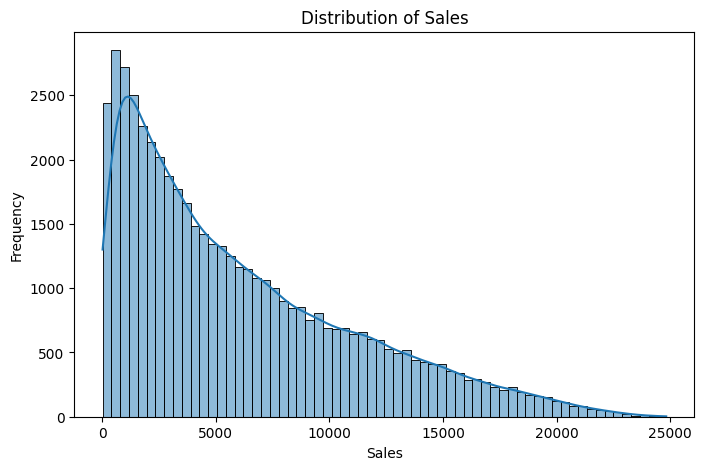

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

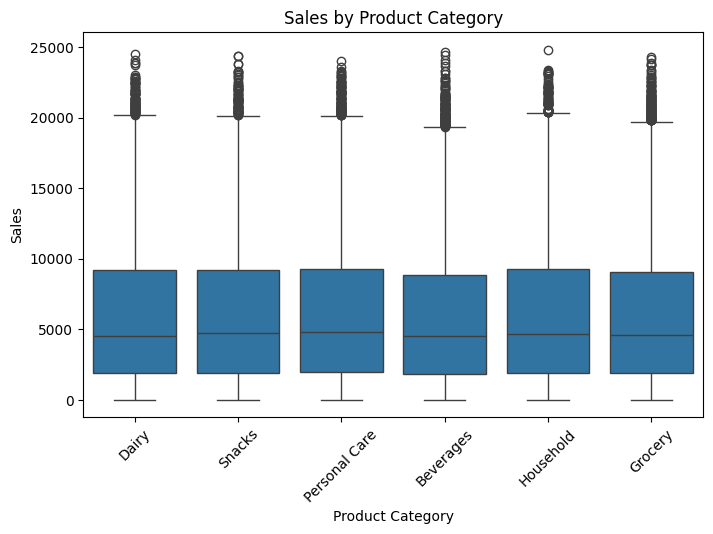

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Product_Category", y="Sales", data=df)
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

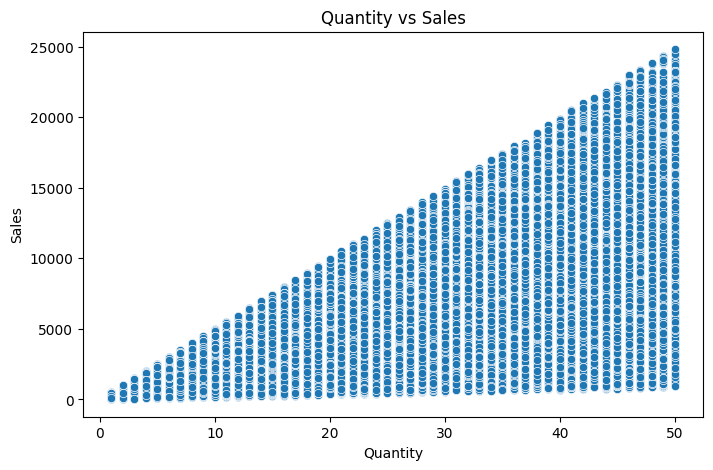

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Quantity", y="Sales", data=df)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

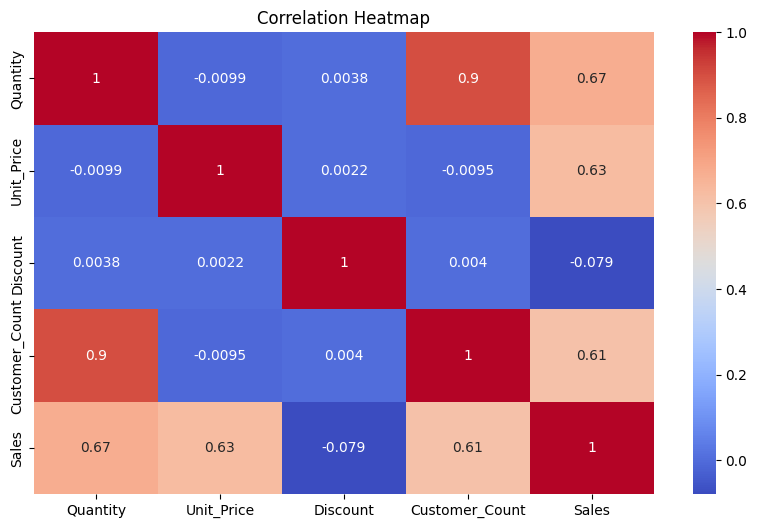

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df["Discount"].describe()

,Discount
count,50000.000000
mean,7.961600
std,6.398261
min,0.000000
25%,0.000000
50%,5.000000
75%,10.000000
max,20.000000


In [ ]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [ ]:
df[["Date", "Month", "Year", "Day_of_Week"]].head()

,Date,Month,Year,Day_of_Week
0,2024-01-01,1,2024,0
1,2024-01-01,1,2024,0
2,2024-01-01,1,2024,0
3,2024-01-01,1,2024,0
4,2024-01-01,1,2024,0


In [ ]:
X = df[["Quantity", "Unit_Price", "Discount", "Customer_Count"]]
y = df["Sales"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X_simple = df[["Quantity"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

LinearRegression()

In [ ]:
y_pred_simple = simple_model.predict(X_test_s)

In [ ]:
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print("Mean Squared Error:", mse_simple)
print("R² Score:", r2_simple)

Mean Squared Error: 14203427.635040546
R² Score: 0.4478063852628472


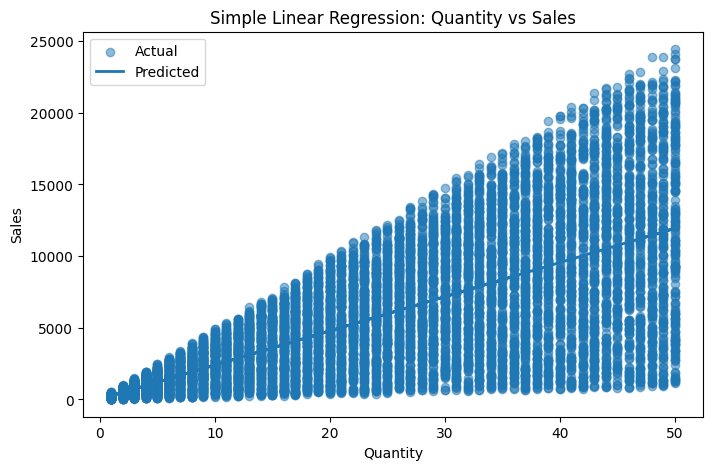

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, alpha=0.5, label="Actual")
plt.plot(X_test_s, y_pred_simple, linewidth=2, label="Predicted")
plt.title("Simple Linear Regression: Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_multiple = multiple_model.predict(X_test)

In [ ]:
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Mean Squared Error:", mse_multiple)
print("R² Score:", r2_multiple)

Mean Squared Error: 3494971.875447822
R² Score: 0.8641242661350941


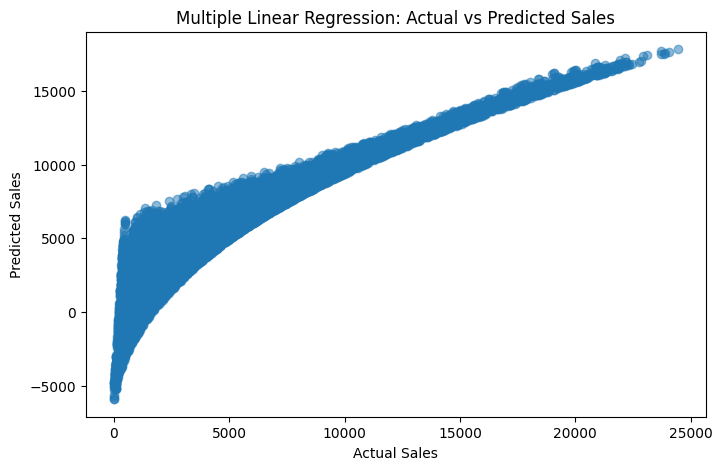

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multiple, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Multiple Linear Regression: Actual vs Predicted Sales")
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_simple)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train_p)

LinearRegression()

In [ ]:
y_pred_poly = poly_model.predict(X_test_p)

In [ ]:
mse_poly = mean_squared_error(y_test_p, y_pred_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)

print("Mean Squared Error:", mse_poly)
print("R² Score:", r2_poly)

Mean Squared Error: 14204592.765570749
R² Score: 0.44776108791240166


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],
    "MSE": [
        mse_simple,
        mse_multiple,
        mse_poly
    ],
    "R2 Score": [
        r2_simple,
        r2_multiple,
        r2_poly
    ]
})

comparison

,Model,MSE,R2 Score
0,Simple Linear Regression,1.420343e+07,0.447806
1,Multiple Linear Regression,3.494972e+06,0.864124
2,Polynomial Regression,1.420459e+07,0.447761


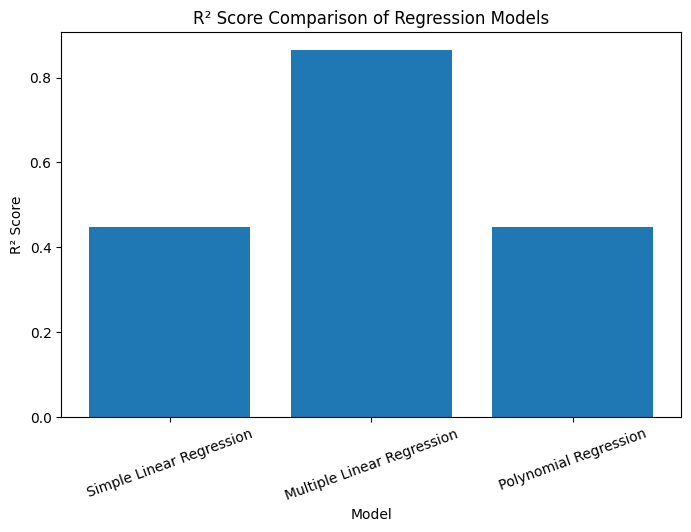

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
comparison.round(4)

,Model,MSE,R2 Score
0,Simple Linear Regression,1.420343e+07,0.4478
1,Multiple Linear Regression,3.494972e+06,0.8641
2,Polynomial Regression,1.420459e+07,0.4478


In [ ]:
print("PROJECT CONCLUSION")
print("------------------")
print("The project compared Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression.")
print("The models were evaluated using Mean Squared Error (MSE) and R² Score.")
print("Multiple Linear Regression used Quantity, Unit_Price, Discount, and Customer_Count as input features.")
print("The final model results are shown in the comparison table above.")

PROJECT CONCLUSION
------------------
The project compared Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression.
The models were evaluated using Mean Squared Error (MSE) and R² Score.
Multiple Linear Regression used Quantity, Unit_Price, Discount, and Customer_Count as input features.
The final model results are shown in the comparison table above.
